# K-Means sur formes colorées

**Algorithme de Lloyd implémenté from scratch** ([src/kmeans.py](../src/kmeans.py)), appliqué au
dataset `shapes_hard_color` : des images 32x32 RGB de six formes (`bar`, `circle`, `cross`, `square`,
`star`, `triangle`) posées sur un fond sombre bruité, avec couleur, taille, position et rotation
tirées aléatoirement.

K-Means est vu comme un algorithme de **quantification vectorielle** :

- `encode(X)` renvoie, pour chaque image, l'indice du centroïde le plus proche : le **code latent discret**.
- `decode(latent)` remplace chaque code par son centroïde : la **reconstruction**.
- `get_codebook()` renvoie les K centroïdes : le **dictionnaire** partagé.

On étudie les trois angles imposés par le sujet : projection / visualisation, compression /
décompression, et génération. Le fil conducteur est expérimental : on fait varier le nombre de
clusters K et le nombre d'initialisations pour mesurer leur effet sur chacun de ces angles.

In [1]:
import sys
from pathlib import Path

# src/ importable et racine du projet comme dossier courant
ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
import os
os.chdir(ROOT)

import numpy as np
import torch
import matplotlib.pyplot as plt

from src.kmeans import KMeans
from src.metrics import compression_report, Latent
from src.dataset import load_shapes_dataset
from src.helper import extract_full_dataset

rng = np.random.default_rng(0)
%matplotlib inline

## 1. Chargement et préparation des données

Les images sont chargées par `ImageFolder` sur le sous-dossier `train`, où les six formes sont
correctement détectées comme classes, puis rassemblées avec `extract_full_dataset`. On fixe la
graine de torch pour que le mélange soit reproductible et on garde un sous-ensemble de 10 000 images,
suffisant pour l'étude et assez léger pour ré-exécuter le notebook rapidement.

Chaque image `(3, 32, 32)` est aplatie à la volée avec `.flatten(start_dim=1)` en un vecteur de 3072
composantes. `ToTensor` a déjà ramené les pixels dans `[0, 1]`, ce qui suffit pour une distance
euclidienne homogène.

In [2]:
torch.manual_seed(0)
dataloader = load_shapes_dataset(data_dir="data/shapes_hard_color/train", batch_size=4096, shuffle=True)
images, shape_labels = extract_full_dataset(dataloader)

class_names = list(dataloader.dataset.classes)

N = 10000
X = images[:N].flatten(start_dim=1).numpy().astype(np.float32)
y = shape_labels[:N].numpy()


def as_image(vec):
    """Reshape a flat pixel vector back to an (H, W, C) RGB image for display."""
    return np.clip(vec, 0.0, 1.0).reshape(3, 32, 32).transpose(1, 2, 0)


print("X:", X.shape, X.dtype, "| pixels dans [", X.min(), ",", X.max(), "]")
print("formes :", class_names)
print("effectifs par forme :", np.bincount(y).tolist())

X: (10000, 3072) float32 | pixels dans [ 0.0 , 1.0 ]
formes : ['bar', 'circle', 'cross', 'square', 'star', 'triangle']
effectifs par forme : [1610, 1691, 1686, 1656, 1726, 1631]


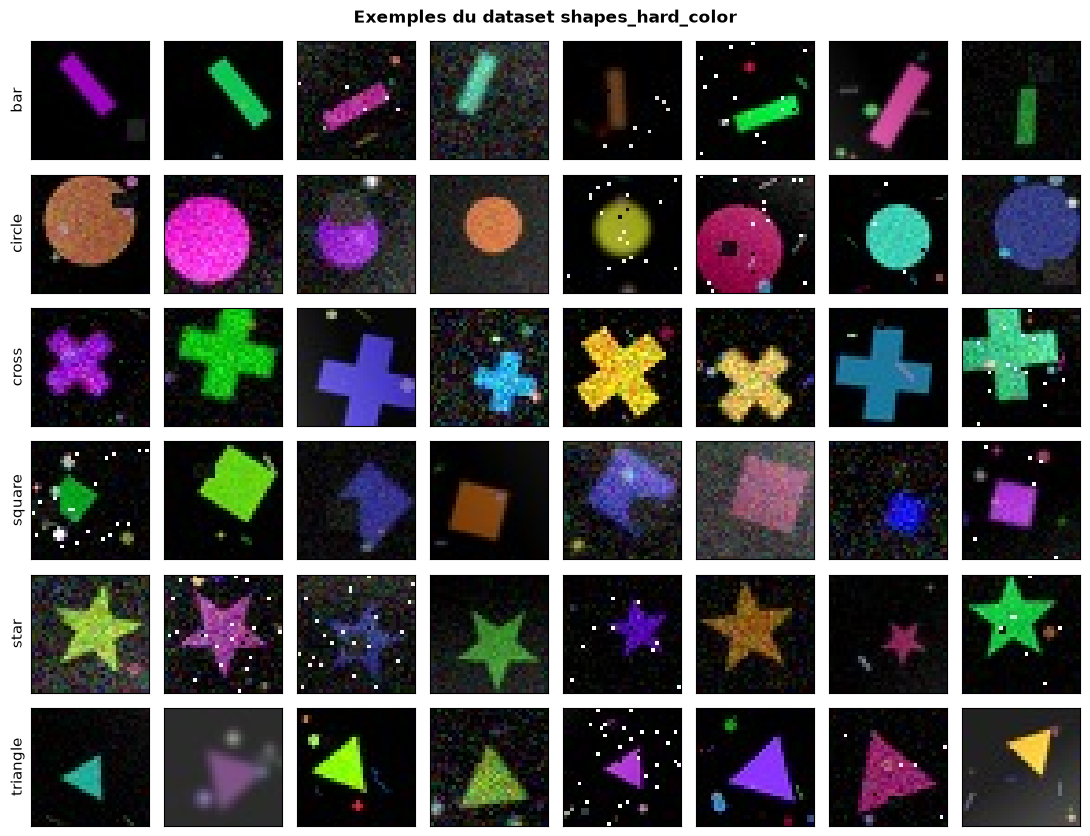

In [3]:
fig, axes = plt.subplots(6, 8, figsize=(11, 8.5))
for r in range(6):
    picks = rng.choice(np.where(y == r)[0], size=8, replace=False)
    for c in range(8):
        axes[r, c].imshow(as_image(X[picks[c]]))
        axes[r, c].set_xticks([]); axes[r, c].set_yticks([])
    axes[r, 0].set_ylabel(class_names[r], fontsize=11)
fig.suptitle("Exemples du dataset shapes_hard_color", fontweight="bold")
plt.tight_layout()
plt.show()

## 2. Entraînement de K-Means

On commence à **k = 6**, une forme par cluster. K-Means minimise l'inertie (somme des distances au
carré des points à leur centroïde) mais peut tomber dans un minimum local selon l'initialisation.
Le paramètre `n_init` lance plusieurs départs indépendants via l'amorçage k-means++ et conserve le
meilleur ; on le règle ici à 10.

In [4]:
kmeans = KMeans(n_clusters=6, n_init=10, max_iter=100, random_state=0)
kmeans.fit(X)

print(f"Inertie    : {kmeans.inertia_:,.0f}")
print(f"Itérations : {kmeans.n_iter_}")
print(f"Centroïdes : {kmeans.centroids_.shape}")

Inertie    : 851,051
Itérations : 30
Centroïdes : (6, 3072)


### Combien d'initialisations ?

Pour mesurer l'utilité de `n_init`, on relance K-Means depuis dix graines différentes avec une seule
initialisation chacune, et on observe la dispersion des inerties obtenues. La courbe du meilleur
résultat cumulé montre à partir de combien d'initialisations l'inertie se stabilise.

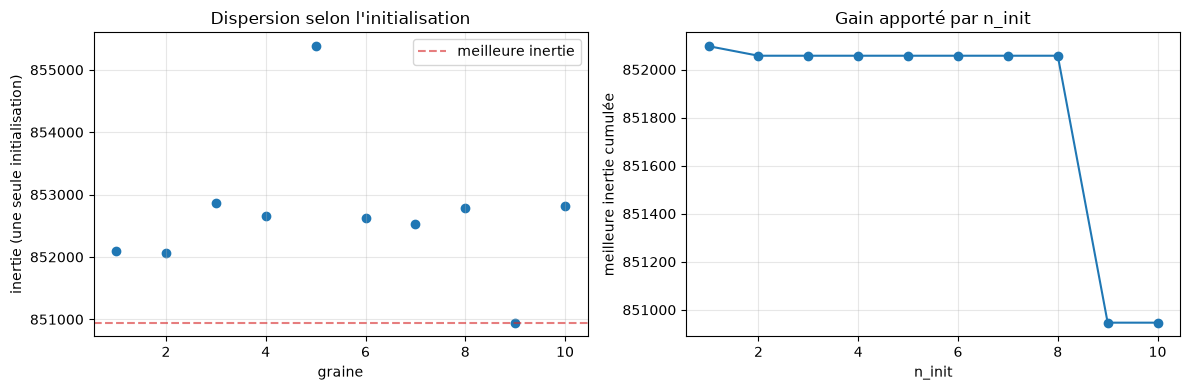

Écart relatif entre la pire et la meilleure initialisation : 0.52%


In [5]:
single_inertias = np.array([
    KMeans(n_clusters=6, n_init=1, max_iter=100, random_state=s).fit(X).inertia_
    for s in range(10)
])
best_so_far = np.minimum.accumulate(single_inertias)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.scatter(range(1, 11), single_inertias, color="tab:blue")
ax1.axhline(single_inertias.min(), color="tab:red", linestyle="--", alpha=0.6, label="meilleure inertie")
ax1.set_xlabel("graine")
ax1.set_ylabel("inertie (une seule initialisation)")
ax1.set_title("Dispersion selon l'initialisation")
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(range(1, 11), best_so_far, "o-")
ax2.set_xlabel("n_init")
ax2.set_ylabel("meilleure inertie cumulée")
ax2.set_title("Gain apporté par n_init")
ax2.grid(alpha=0.3)
plt.tight_layout()
plt.show()

spread = (single_inertias.max() - single_inertias.min()) / single_inertias.min()
print(f"Écart relatif entre la pire et la meilleure initialisation : {spread:.2%}")

## 3. Projection et visualisation

### 3.1 Le dictionnaire à k = 6

Chaque centroïde se réaffiche en image 32x32 RGB. Ce sont les **prototypes** appris : une couleur
dominante et une tache centrale floue, la moyenne d'un cluster effaçant la forme précise.

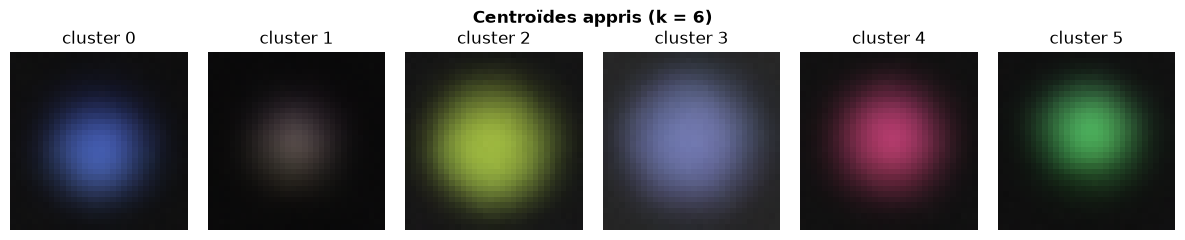

In [7]:
fig, axes = plt.subplots(1, 6, figsize=(12, 2.4))
for k, ax in enumerate(axes):
    ax.imshow(as_image(kmeans.centroids_[k]))
    ax.set_title(f"cluster {k}")
    ax.axis("off")
fig.suptitle("Centroïdes appris (k = 6)", fontweight="bold")
plt.tight_layout()
plt.show()

### 3.2 Contenu des clusters

Les lignes sont +/- homogènes en couleur mais mélangent les formes : le regroupement se fait surtout par teinte dominante, pas par géométrie.

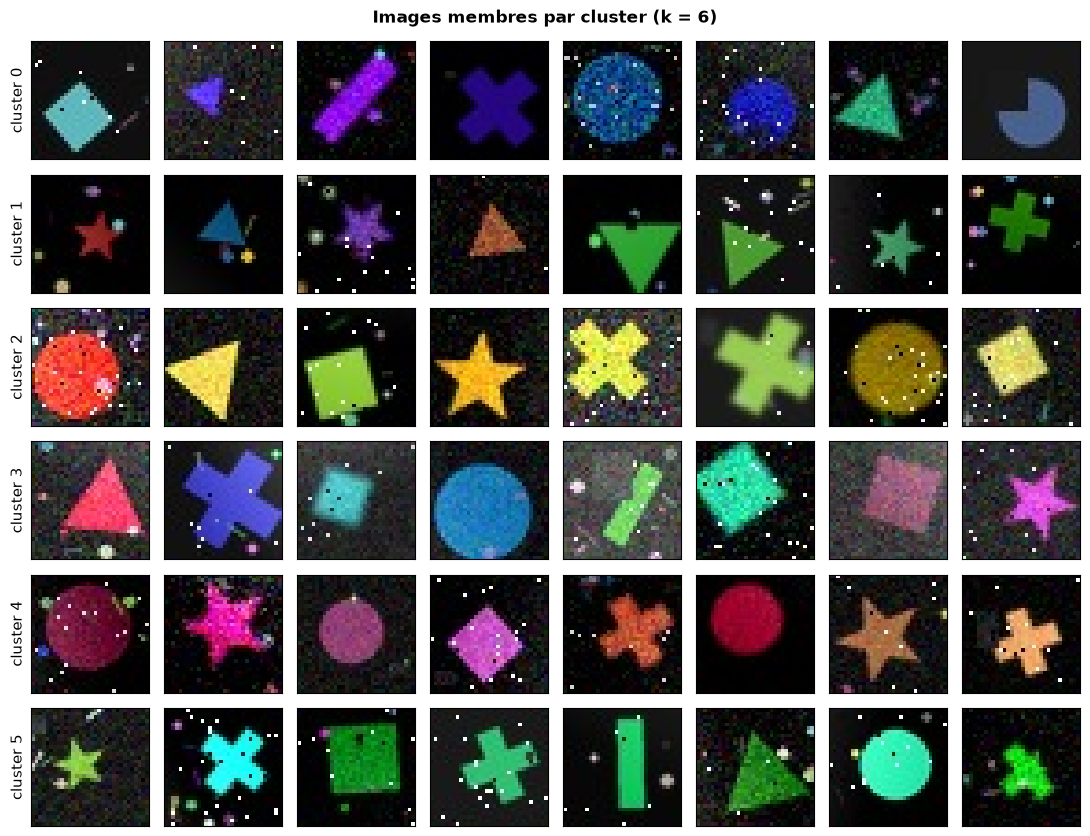

In [8]:
fig, axes = plt.subplots(6, 8, figsize=(11, 8.5))
for c in range(6):
    members = np.where(kmeans.labels_ == c)[0]
    picks = rng.choice(members, size=8, replace=False)
    for j in range(8):
        axes[c, j].imshow(as_image(X[picks[j]]))
        axes[c, j].set_xticks([]); axes[c, j].set_yticks([])
    axes[c, 0].set_ylabel(f"cluster {c}", fontsize=11)
fig.suptitle("Images membres par cluster (k = 6)", fontweight="bold")
plt.tight_layout()
plt.show()

### 3.3 kmeans_64

En augmentant K, le dictionnaire devient une palette de prototypes bien plus fine. Ils couvrent densément l'espace des couleurs mais
restent presque tous des taches floues, où la forme n'apparaît pratiquement pas. K-Means dépense sa
capacité à raffiner la couleur, pas la géométrie.

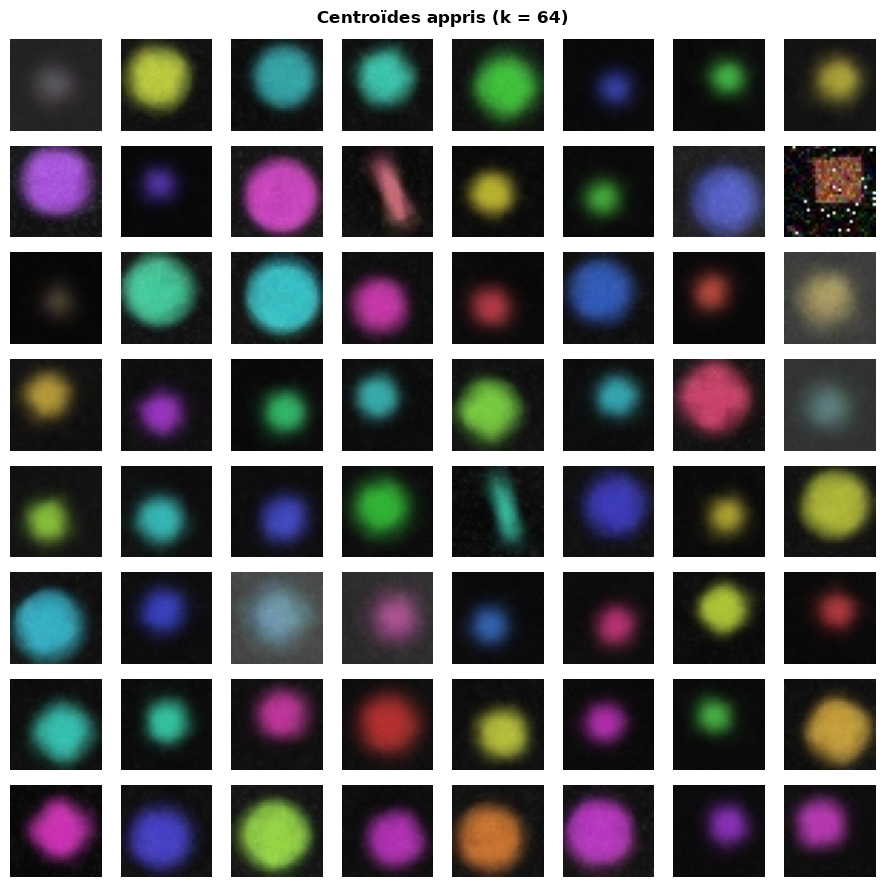

In [9]:
kmeans_64 = KMeans(n_clusters=64, n_init=2, max_iter=100, random_state=0)
kmeans_64.fit(X)

fig, axes = plt.subplots(8, 8, figsize=(9, 9))
for k, ax in enumerate(axes.ravel()):
    ax.imshow(as_image(kmeans_64.centroids_[k]))
    ax.axis("off")
fig.suptitle("Centroïdes appris (k = 64)", fontweight="bold")
plt.tight_layout()
plt.show()

## 4. Compression et décompression

On encode le jeu (chaque image devient un entier de cluster), puis on décode (chaque entier redevient
son centroïde). `compression_report` mesure le poids du dictionnaire, celui des codes et la MSE de
reconstruction.

À k = 6 le gain est énorme : un entier par image plus six centroïdes partagés, au lieu de 3072
flottants par image. En contrepartie, toutes les images d'un cluster se reconstruisent en une seule
tache de couleur, d'où une MSE élevée.

In [10]:
latent = kmeans.encode(X)
X_rec = kmeans.decode(latent)

report = compression_report(kmeans.get_codebook(), latent, X, X_rec)
for key, value in report.items():
    print(f"{key:>24} : {value}")

           latent_nature : discrete
          codebook_bytes : 73728
            latent_bytes : 10000
  total_compressed_bytes : 83728
          original_bytes : 122880000
       compression_ratio : 1467.6094018727308
      reconstruction_mse : 0.027703486382961273


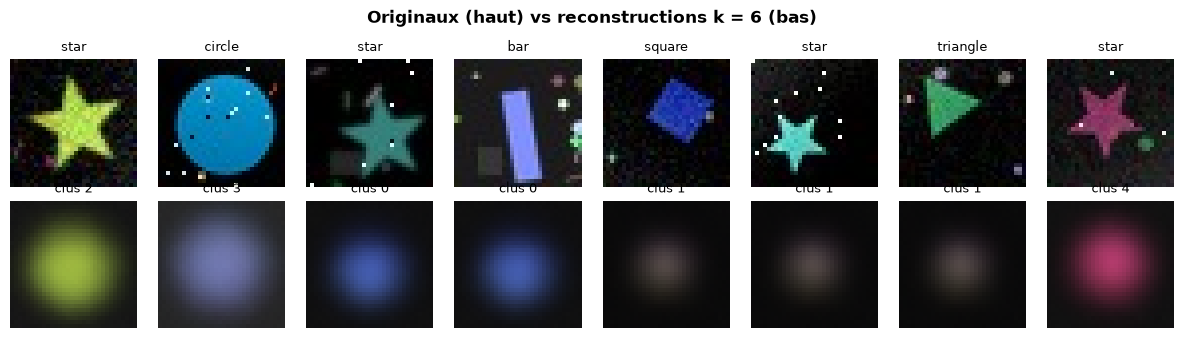

In [11]:
sample_idx = rng.choice(N, size=8, replace=False)
fig, axes = plt.subplots(2, 8, figsize=(12, 3.4))
for col, i in enumerate(sample_idx):
    axes[0, col].imshow(as_image(X[i]))
    axes[0, col].set_title(class_names[y[i]], fontsize=9)
    axes[0, col].axis("off")
    axes[1, col].imshow(as_image(X_rec[i]))
    axes[1, col].set_title(f"clus {latent.array[i]}", fontsize=9)
    axes[1, col].axis("off")
fig.suptitle("Originaux (haut) vs reconstructions k = 6 (bas)", fontweight="bold")
plt.tight_layout()
plt.show()

### Effet de K sur le compromis débit / qualité

On balaie K et, pour chaque valeur, on entraîne un modèle et on mesure l'inertie, la MSE de
reconstruction, le ratio de compression et l'accord avec les formes réelles. Augmenter K enrichit le
dictionnaire : la reconstruction s'améliore, mais le ratio de compression baisse puisque le
dictionnaire pèse plus lourd.

In [12]:
def majority_vote_accuracy(labels_pred, labels_true, n_clusters, n_classes=6):
    mapping = {}
    for c in range(n_clusters):
        members = labels_true[labels_pred == c]
        mapping[c] = np.bincount(members, minlength=n_classes).argmax() if members.size else -1
    mapped = np.array([mapping[c] for c in labels_pred])
    return (mapped == labels_true).mean(), mapping


k_values = [6, 16, 36, 64, 100, 200]
models = {6: kmeans, 64: kmeans_64}  # réutilise les modèles déjà entraînés
sweep = []
for k in k_values:
    model = models.get(k) or KMeans(n_clusters=k, n_init=2, max_iter=60, random_state=0).fit(X)
    models[k] = model
    lat = model.encode(X)
    rep = compression_report(model.get_codebook(), lat, X, model.decode(lat))
    acc, _ = majority_vote_accuracy(model.labels_, y, k)
    sweep.append((k, model.inertia_, rep["reconstruction_mse"], rep["compression_ratio"], acc))
    print(f"k = {k:3d}  ->  inertie = {model.inertia_:11,.0f}  |  MSE = {rep['reconstruction_mse']:.5f}"
          f"  |  ratio = {rep['compression_ratio']:8.1f}  |  précision forme = {acc:.2%}")

k =   6  ->  inertie =     851,051  |  MSE = 0.02770  |  ratio =   1467.6  |  précision forme = 26.29%


k =  16  ->  inertie =     749,879  |  MSE = 0.02441  |  ratio =    594.7  |  précision forme = 28.08%


k =  36  ->  inertie =     671,627  |  MSE = 0.02186  |  ratio =    271.6  |  précision forme = 30.46%
k =  64  ->  inertie =     625,388  |  MSE = 0.02036  |  ratio =    154.3  |  précision forme = 31.51%


k = 100  ->  inertie =     598,717  |  MSE = 0.01949  |  ratio =     99.2  |  précision forme = 33.67%


k = 200  ->  inertie =     559,151  |  MSE = 0.01820  |  ratio =     49.8  |  précision forme = 37.70%


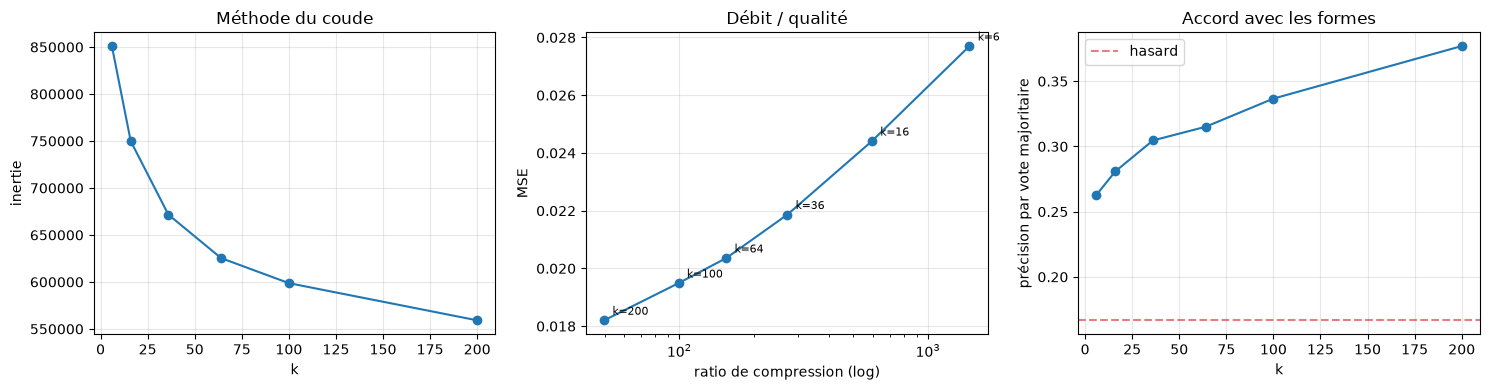

In [13]:
ks = [r[0] for r in sweep]
inertias = [r[1] for r in sweep]
mses = [r[2] for r in sweep]
ratios = [r[3] for r in sweep]
accs = [r[4] for r in sweep]

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 4))
ax1.plot(ks, inertias, "o-")
ax1.set_xlabel("k"); ax1.set_ylabel("inertie"); ax1.set_title("Méthode du coude")
ax1.grid(alpha=0.3)

ax2.plot(ratios, mses, "o-")
for k, mse, ratio in zip(ks, mses, ratios):
    ax2.annotate(f"k={k}", (ratio, mse), textcoords="offset points", xytext=(6, 4), fontsize=8)
ax2.set_xscale("log")
ax2.set_xlabel("ratio de compression (log)"); ax2.set_ylabel("MSE"); ax2.set_title("Débit / qualité")
ax2.grid(alpha=0.3)

ax3.plot(ks, accs, "o-")
ax3.axhline(1 / 6, color="tab:red", linestyle="--", alpha=0.6, label="hasard")
ax3.set_xlabel("k"); ax3.set_ylabel("précision par vote majoritaire"); ax3.set_title("Accord avec les formes")
ax3.legend(); ax3.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Visualisons l'effet de K sur la reconstruction elle-même, en comparant les mêmes images à k = 6 et
à k = 200. À k = 6 chaque image se réduit à une tache floue ; à k = 200 les couleurs deviennent
fidèles et quelques images laissent deviner leur forme, même si la plupart
restent des taches.

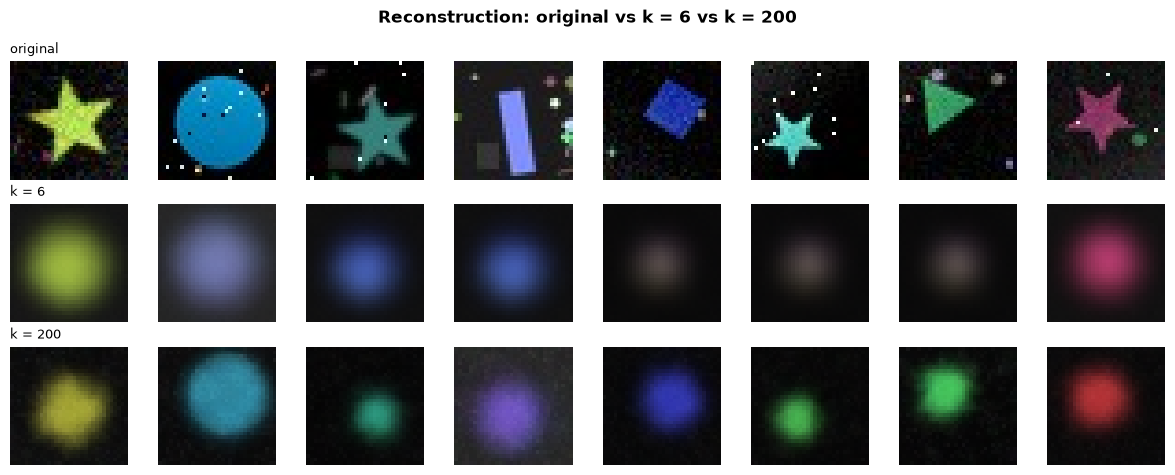

In [14]:
model_hi = models[200]
X_rec_hi = model_hi.decode(model_hi.encode(X))

fig, axes = plt.subplots(3, 8, figsize=(12, 4.8))
for col, i in enumerate(sample_idx):
    axes[0, col].imshow(as_image(X[i]));        axes[0, col].axis("off")
    axes[1, col].imshow(as_image(X_rec[i]));    axes[1, col].axis("off")
    axes[2, col].imshow(as_image(X_rec_hi[i])); axes[2, col].axis("off")
axes[0, 0].set_title("original", fontsize=9, loc="left")
axes[1, 0].set_title("k = 6", fontsize=9, loc="left")
axes[2, 0].set_title("k = 200", fontsize=9, loc="left")
fig.suptitle("Reconstruction: original vs k = 6 vs k = 200", fontweight="bold")
plt.tight_layout()
plt.show()

## 5. Les clusters correspondent-ils aux formes ?

K-Means ignore les étiquettes ; on mesure a posteriori le lien avec les formes en attribuant à chaque
cluster sa forme majoritaire, puis en calculant la précision de ce classement induit. La table de
contingence croise clusters et formes.

In [15]:
acc, mapping = majority_vote_accuracy(kmeans.labels_, y, 6)
print(f"Précision par vote majoritaire (forme, k = 6) : {acc:.2%}")
print(f"Niveau du hasard (6 formes équilibrées)       : {1 / 6:.2%}\n")
for c in range(6):
    counts = np.bincount(y[kmeans.labels_ == c], minlength=6)
    purity = counts.max() / counts.sum()
    print(f"cluster {c}: forme dominante = {class_names[mapping[c]]:>8}  |  pureté = {purity:5.1%}  |  taille = {counts.sum()}")

Précision par vote majoritaire (forme, k = 6) : 26.29%
Niveau du hasard (6 formes équilibrées)       : 16.67%

cluster 0: forme dominante =    cross  |  pureté = 19.5%  |  taille = 1545
cluster 1: forme dominante =      bar  |  pureté = 28.2%  |  taille = 3309
cluster 2: forme dominante =   circle  |  pureté = 38.0%  |  taille = 879
cluster 3: forme dominante =   circle  |  pureté = 42.2%  |  taille = 864
cluster 4: forme dominante =   circle  |  pureté = 22.0%  |  taille = 1678
cluster 5: forme dominante =     star  |  pureté = 19.0%  |  taille = 1725


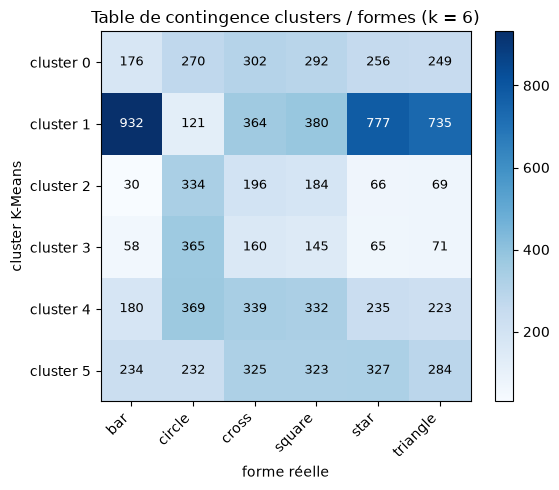

In [16]:
contingency = np.zeros((6, 6), dtype=int)
for c in range(6):
    contingency[c] = np.bincount(y[kmeans.labels_ == c], minlength=6)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(contingency, cmap="Blues")
ax.set_xticks(range(6)); ax.set_xticklabels(class_names, rotation=45, ha="right")
ax.set_yticks(range(6)); ax.set_yticklabels([f"cluster {c}" for c in range(6)])
ax.set_xlabel("forme réelle"); ax.set_ylabel("cluster K-Means")
for c in range(6):
    for s in range(6):
        ax.text(s, c, contingency[c, s], ha="center", va="center",
                color="white" if contingency[c, s] > contingency.max() / 2 else "black", fontsize=9)
ax.set_title("Table de contingence clusters / formes (k = 6)")
fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()

La précision reste proche du hasard et, comme l'a montré le balayage, ne progresse que lentement
avec K : les clusters supplémentaires raffinent surtout la couleur et la position, pas la forme. Sur
pixels bruts RGB, la distance euclidienne est dominée par la couleur, puis par la pose ; l'identité
de forme demanderait une représentation invariante à ces deux facteurs.

## 6. Génération de données

Vu comme modèle génératif, K-Means définit une catégorielle sur les K codes (fréquences empiriques
des clusters) suivie d'un décodage déterministe vers le centroïde. On tire un code selon cette loi et
on renvoie le centroïde correspondant. On compare la génération à k = 6 et à k = 64 pour voir le
vocabulaire s'enrichir.

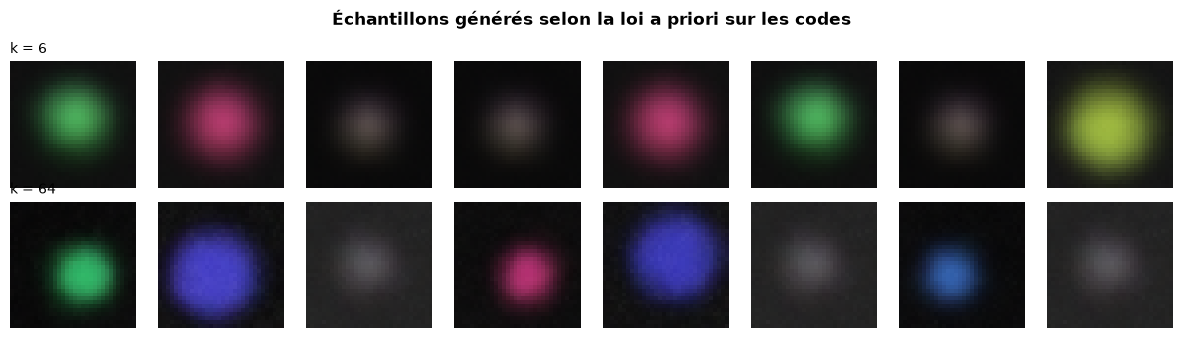

In [17]:
def sample_from(model, n_samples):
    prior = np.bincount(model.labels_, minlength=model.n_clusters) / len(model.labels_)
    codes = Latent(array=rng.choice(model.n_clusters, size=n_samples, p=prior), nature="discrete")
    return codes.array, model.decode(codes)


fig, axes = plt.subplots(2, 8, figsize=(12, 3.4))
for row, model in enumerate([kmeans, kmeans_64]):
    codes, gen = sample_from(model, 8)
    for col in range(8):
        axes[row, col].imshow(as_image(gen[col]))
        axes[row, col].axis("off")
    axes[row, 0].set_title(f"k = {model.n_clusters}", fontsize=10, loc="left")
fig.suptitle("Échantillons générés selon la loi a priori sur les codes", fontweight="bold")
plt.tight_layout()
plt.show()

L'ensemble des images générables se réduit exactement aux K centroïdes : le modèle ne crée aucune
forme ni couleur inédite, seulement des répétitions de ses prototypes pondérées par la loi a priori.
Augmenter K enrichit ce vocabulaire sans jamais atteindre une vraie diversité, ce qui motive les
modèles à espace latent continu.

## 7. Conclusions

- **Projection / visualisation** : les centroïdes sont des prototypes chromatiques ; le contenu des
  clusters confirme un regroupement par teinte dominante plutôt que par forme. Un dictionnaire plus
  grand couvre plus finement l'espace couleur.
- **Compression / décompression** : à k = 6 le gain est maximal mais la reconstruction grossière.
  Le balayage de K trace un compromis débit / qualité clair : monter K améliore la reconstruction et
  fait chuter le ratio de compression.
- **Génération** : le modèle induit est une catégorielle sur K prototypes ; il ne produit rien de
  nouveau, ce qui illustre la faiblesse générative de K-Means.
- **Clusters vs formes** : la précision par vote majoritaire reste proche du hasard, même en montant
  K, car la distance euclidienne sur pixels bruts est dominée par la couleur puis la pose. Séparer
  les formes demanderait une représentation invariante à la couleur et à la pose.
- **Initialisation** : l'amorçage k-means++ suivi de plusieurs `n_init` stabilise l'inertie ; au-delà
  de quelques initialisations, le gain devient marginal.